# PHYT1D — Module 09: Experimental Scenarios (UVa/Padova Validation)

Implements all four scenario families from Section 11:

| Scenario | Variable | Levels | Exercise |
|----------|----------|--------|----------|
| S1 | Exercise intensity | rest, 10%, 25%, 50%, 60%, 75%, 90% VO₂max | Non-Aerobic - Aerobic, 60 min, 17:00 - 18:00 |
| S2 | Exercise duration | 15, 30, 45, 60, 75, 90, 105, 120 min | Aerobic, 50%, 16:00 - 18:00 |
| S3 | Meal bolus × factor | ×0.4–×1.6 (6 levels) | Rest |
| S4 | CHO × factor | ×0.7–×1.3 (6 levels) | Rest |

Total: 27 levels × 50 virtual subjects = 1350 T1DS simulations.

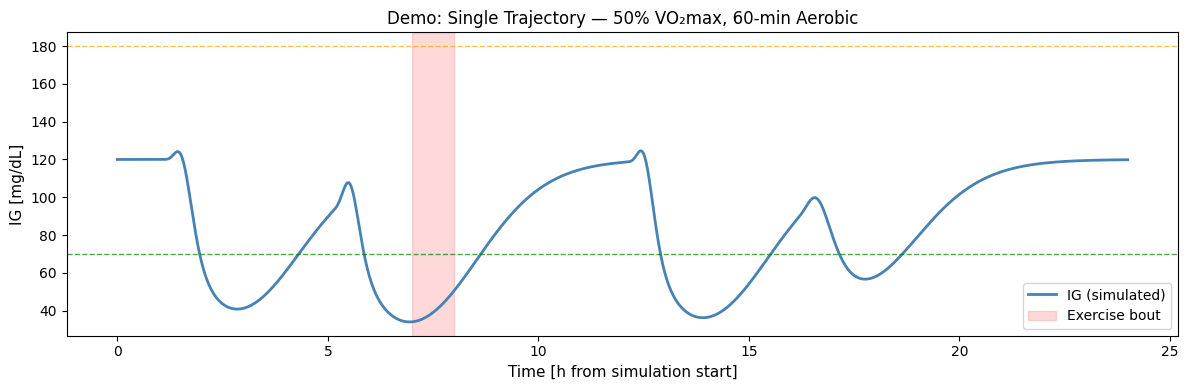

✓ Simulator module ready.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Bring forward-model and evaluation functions into namespace (filenames
# start with digits so they can't be imported; %run reads the file directly).
%run 06_simulator.ipynb
%run 08_evaluation_metrics.ipynb

## 9.1 Scenario Definitions

In [9]:
def get_scenario_S1_configs():
    """
    Scenario 1 — Exercise Intensity Modulation.
    Aerobic, 60 min, start 14:00. Intensity: rest, 25%, 50%, 75% VO2max.
    Tests: beta_aer, tau_on, tau_post, VO2max scaling.
    """
    base = {
        "d": 60.0, "t_start": 420.0, "exercise_type": "aerobic",
        "CR": 15.0,
        "CHO_BF": 45.0, "CHO_LU": 70.0, "CHO_DN": 60.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 300.0, "t_DN": 720.0, "t_SN": 960.0,
        "bolus_factor": 1.0, "CHO_factor": 1.0, "sex": "M", "age_group": "adult",
    }
    configs = []
    for u in [0.0, 0.1, 0.25, 0.50, 0.6, 0.75, 0.9]:
        cfg = base.copy(); cfg["u"] = u
        cfg["label"] = "Rest" if u == 0 else f"{int(u*100)}% VO₂max"
        configs.append(cfg)
    return configs


def get_scenario_S2_configs():
    """
    Scenario 2 — Exercise Duration Modulation.
    Aerobic, 50% VO2max, start 14:00. Durations: 60, 90, 120 min.
    Tests: tau_post duration dependence; 2-hr bout ends 16:00, dinner at 19:00.
    """
    base = {
        "u": 0.50, "t_start": 420.0, "exercise_type": "aerobic",
        "CR": 15.0,
        "CHO_BF": 45.0, "CHO_LU": 70.0, "CHO_DN": 60.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 300.0, "t_DN": 720.0, "t_SN": 960.0,
        "bolus_factor": 1.0, "CHO_factor": 1.0, "sex": "M", "age_group": "adult",
    }
    configs = []
    for d in [15.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0]:
        cfg = base.copy(); cfg["d"] = d; cfg["label"] = f"{int(d)} min"
        configs.append(cfg)
    return configs


def get_scenario_S3_configs():
    """
    Scenario 3 — Meal Bolus Modulation.
    Rest (no exercise). Bolus × factor: 0.4, 0.6, 0.8, 1.2, 1.4, 1.6.
    Tests: SI, kd, ka2 under extreme bolus errors.
    """
    base = {
        "u": 0.0, "d": 0.0, "t_start": 420.0, "exercise_type": "aerobic",
        "CR": 15.0,
        "CHO_BF": 45.0, "CHO_LU": 70.0, "CHO_DN": 60.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 300.0, "t_DN": 720.0, "t_SN": 960.0,
        "CHO_factor": 1.0, "sex": "M", "age_group": "adult",
    }
    configs = []
    for bf in [0.4, 0.6, 0.8, 1.2, 1.4, 1.6]:
        cfg = base.copy(); cfg["bolus_factor"] = bf
        pct = int((bf-1)*100)
        cfg["label"] = f"{'+' if pct>=0 else ''}{pct}% bolus"
        configs.append(cfg)
    return configs


def get_scenario_S4_configs():
    """
    Scenario 4 — CHO Amount Modulation.
    Rest (no exercise). All CHO × factor: 0.7, 0.8, 0.9, 1.1, 1.2, 1.3.
    Bolus recomputed: Bolus = CHO*factor/CR.
    Tests: kempt, kabs under varying Ra(t).
    """
    base = {
        "u": 0.0, "d": 0.0, "t_start": 420.0, "exercise_type": "aerobic",
        "CR": 15.0,
        "CHO_BF": 45.0, "CHO_LU": 70.0, "CHO_DN": 60.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 300.0, "t_DN": 720.0, "t_SN": 960.0,
        "bolus_factor": 1.0, "sex": "M", "age_group": "adult",
    }
    configs = []
    for cf in [0.7, 0.8, 0.9, 1.1, 1.2, 1.3]:
        cfg = base.copy(); cfg["CHO_factor"] = cf
        pct = int((cf-1)*100)
        cfg["label"] = f"{'+' if pct>=0 else ''}{pct}% CHO"
        configs.append(cfg)
    return configs


ALL_SCENARIO_CONFIGS = {
    "S1": get_scenario_S1_configs(),
    "S2": get_scenario_S2_configs(),
    "S3": get_scenario_S3_configs(),
    "S4": get_scenario_S4_configs(),
}
print("Scenario counts:", {k: len(v) for k, v in ALL_SCENARIO_CONFIGS.items()})
print(f"Total levels: {sum(len(v) for v in ALL_SCENARIO_CONFIGS.values())}")

Scenario counts: {'S1': 7, 'S2': 8, 'S3': 6, 'S4': 6}
Total levels: 27


## 9.2 Run All Scenarios

In [10]:
def run_scenario_family(scenario_configs, theta_A, theta_B, fixed, dt=1.0, T=1440):
    """
    Run a scenario family (S1–S4) for a given virtual subject.

    Parameters
    ----------
    scenario_configs : list of dicts — one dict per scenario level
    theta_A          : dict — Group A parameters
    theta_B          : dict — Group B parameters
    fixed            : dict — Group D parameters

    Returns
    -------
    results : list of dicts — {label, times, IG, G, user_params}
    """
    # simulate_trajectory provided by %run 06_simulator.ipynb at top of notebook
    results = []
    for cfg in scenario_configs:
        times, ig, g = simulate_trajectory(theta_A, theta_B, cfg, fixed, dt, T)
        results.append({
            "label"      : cfg["label"],
            "times"      : times,
            "IG"         : ig,
            "G"          : g,
            "user_params": cfg,
        })
    return results

## 9.3 MARD Profile Plot (Figure 9 style)

In [11]:
def plot_MARD_profile(scenario_results_dict, ig_true_dict, ax=None, threshold=10.0):
    """
    Plot MARD [%] across all scenario levels (Figure 9 style).

    Parameters
    ----------
    scenario_results_dict : dict — {scenario: [{label, IG}, ...]}
    ig_true_dict          : dict — {scenario: [{label, IG_true}, ...]}
    ax                    : matplotlib Axes | None
    threshold             : float — pass line [%]
    """
    # MARD provided by %run 08_evaluation_metrics.ipynb at top of notebook
    if ax is None:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    else:
        axes = ax

    colors = {"S1":"steelblue","S2":"darkorange","S3":"forestgreen","S4":"crimson"}
    scenario_names = {"S1":"S1: Intensity","S2":"S2: Duration",
                      "S3":"S3: Bolus","S4":"S4: CHO"}

    for i, (sc, res_list) in enumerate(scenario_results_dict.items()):
        ax_i = axes[i]
        labels = [r["label"] for r in res_list]
        mards  = []
        for j, r in enumerate(res_list):
            ig_true = ig_true_dict[sc][j]["IG"]
            mards.append(MARD(ig_true, r["IG"]))
        ax_i.bar(labels, mards, color=colors.get(sc,"grey"), alpha=0.8)
        ax_i.axhline(threshold, color="red", ls="--", lw=1.5, label=f"{threshold}% threshold")
        ax_i.set_title(scenario_names[sc], fontsize=11)
        ax_i.set_ylabel("MARD [%]" if i==0 else "")
        ax_i.tick_params(axis="x", rotation=30)
        ax_i.set_ylim(0, 14)

    plt.suptitle("Figure 9 — MARD Profile Across Scenario Levels", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("scenario_MARD_profile.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9.4 24-Hour Glucose Profile Plot

In [12]:
def plot_scenario_family(results, title="Scenario", figsize=(12, 5)):
    """
    Plot 24-hour IG trajectories for all levels in a scenario family.

    Parameters
    ----------
    results : list of dicts — output from run_scenario_family
    title   : str
    """
    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(results)))

    for r, col in zip(results, cmap):
        ax.plot(r["times"]/60, r["IG"], color=col, lw=2, label=r["label"])

    ax.axhline(70,  color="green",  ls="--", lw=1, alpha=0.6, label="70 mg/dL")
    ax.axhline(180, color="orange", ls="--", lw=1, alpha=0.6, label="180 mg/dL")
    ax.fill_between([0, 24], 70, 180, alpha=0.06, color="green")

    # Mark exercise window if active
    u = results[0]["user_params"].get("u", 0)
    if u > 0:
        ts = results[0]["user_params"]["t_start"] / 60
        for r in results:
            te = ts + r["user_params"]["d"] / 60
        ax.axvspan(ts, te, alpha=0.10, color="red", label="Exercise")

    ax.set_xlabel("Time [h]", fontsize=11)
    ax.set_ylabel("IG [mg/dL]", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.savefig(f"scenario_{title.replace(' ','_')}.png", dpi=150)
    plt.show()
